# Accelerated Data Science with RAPIDS #

Transition Path: cuDF provides a way for users to scale their pandas workflows as data sizes grow, offering a middle ground between single-threaded pandas and distributed computing solutions like Dask or Apache Spark .

## 09 - Introduction to Dask cuDF ##

**Table of Contents**
<br>
[Dask](https://dask.org/) cuDF can be used to distribute dataframe operations to multiple GPUs. In this notebook we will introduce some key Dask concepts, learn how to setup a Dask cluster for utilizing multiple GPUs, and see how to perform simple dataframe operations on distributed Dask dataframes. This notebook covers the below sections:
1. [An Introduction to Dask](#An-Introduction-to-Dask)
2. [Setting up a Dask Scheduler](#Setting-up-a-Dask-Scheduler)
    * [Obtaining the Local IP Address](#Obtaining-the-Local-IP-Address)
    * [Starting a `LocalCUDACluster`](#Starting-a-LocalCUDACluster)
    * [Instantiating a Client Connection](#Instantiating-a-Client-Connection)
    * [The Dask Dashboard](#The-Dask-Dashboard)
3. [Reading Data with Dask cuDF](#Reading-Data-with-Dask-cuDF)
4. [Computational Graph](#Computational-Graph)
    * [Visualizing the Computational Graph](#Visualizing-the-Computational-Graph)
    * [Extending the Computational Graph](#Extending-the-Computational-Graph)
    * [Computing with the Computational Graph](#Computing-with-the-Computational-Graph)
    * [Persisting Data in the Cluster](#Persisting-Data-in-the-Cluster)
6. [Initial Data Exploration with Dask cuDF](#Initial-Data-Exploration-with-Dask-cuDF)
    * [Exercise #1 - Counties North of Sunderland with Dask](#Exercise-#1---Counties-North-of-Sunderland-with-Dask)

## An Introduction to Dask ##
[Dask](https://dask.org/) is a Python library for parallel computing. In Dask programming, we create computational graphs that define code we **would like** to execute, and then, give these computational graphs to a Dask scheduler which evaluates them lazily, and efficiently, in parallel.

In addition to using multiple CPU cores or threads to execute computational graphs in parallel, Dask schedulers can also be configured to execute computational graphs on multiple CPUs, or, as we will do in this workshop, multiple GPUs. As a result, Dask programming facilitates operating on data sets that are larger than the memory of a single compute resource.

Because Dask computational graphs can consist of arbitrary Python code, they provide [a level of control and flexibility superior to many other systems](https://docs.dask.org/en/latest/spark.html) that can operate on massive data sets. However, we will focus for this workshop primarily on the Dask DataFrame, one of several data structures whose operations and methods natively utilize Dask's parallel scheduling:
* Dask DataFrame, which closely resembles the Pandas DataFrame
* Dask Array, which closely resembles the NumPy ndarray
* Dask Bag, a set which allows duplicates and can hold heterogeneously-typed data

In particular, we will use a Dask-cuDF dataframe, which combines the interface of Dask with the GPU power of cuDF for distributed dataframe operations on multiple GPUs. We will now turn our attention to utilizing all 4 NVIDIA V100 GPUs in this environment for operations on an 18GB UK population data set that would not fit into the memory of a single 16GB GPU.

## Setting up a Dask Scheduler ##
We begin by starting a Dask scheduler which will take care to distribute our work across the 4 available GPUs. In order to do this we need to start a `LocalCUDACluster` instance, using our host machine's IP, and then instantiate a client that can communicate with the cluster.

### Obtaining the Local IP Address ###

In [1]:
import subprocess # we will use this to obtain our local IP using the following command
cmd = "hostname --all-ip-addresses"

process = subprocess.Popen(cmd.split(), stdout=subprocess.PIPE)
output, error = process.communicate()
IPADDR = str(output.decode()).split()[0]

### Starting a `LocalCUDACluster` ###
`dask_cuda` provides utilities for Dask and CUDA (the "cu" in cuDF) interactions.

In [2]:
from dask_cuda import LocalCUDACluster
cluster = LocalCUDACluster(ip=IPADDR)

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:   tcp://172.28.0.12:41851
INFO:distributed.scheduler:  dashboard at:  http://172.28.0.12:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://172.28.0.12:43905'
INFO:distributed.scheduler:Register worker addr: tcp://172.28.0.12:39283 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.28.0.12:39283
INFO:distributed.core:Starting established connection to tcp://172.28.0.12:42034


### Instantiating a Client Connection ###
The `dask.distributed` library gives us distributed functionality, including the ability to connect to the CUDA Cluster we just created. The `progress` import will give us a handy progress bar we can utilize below.

In [3]:
from dask.distributed import Client, progress

client = Client(cluster)

INFO:distributed.scheduler:Receive client connection: Client-563e87f8-8592-11f1-8112-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://172.28.0.12:38706


In [4]:
dashboard_link = getattr(client, "dashboard_link", None)

try:
    from google.colab import output
    from IPython.display import display, Markdown

    try:
        dashboard_url = output.serve_kernel_port_as_url(8787)
        display(Markdown(f"[Open the Dask dashboard in a new tab]({dashboard_url})"))
    except Exception as url_error:
        print(f"Could not create a Colab proxy URL for port 8787: {url_error}")
        if dashboard_link:
            print(f"Open the dashboard here instead: {dashboard_link}")
except Exception:
    if dashboard_link:
        print(f"Open the dashboard here: {dashboard_link}")
    else:
        print("Dask dashboard link is not available yet. Make sure the client was created successfully.")

Could not create a Colab proxy URL for port 8787: module 'google.colab.output' has no attribute 'serve_kernel_port_as_url'
Open the dashboard here instead: http://172.28.0.12:8787/status


### The Dask Dashboard

Dask ships with a very helpful dashboard that in our case runs on port `8787`. In Google Colab, the dashboard is not opened with a raw `:8787` browser URL. Instead, use the Colab port proxy cell above to display it inside the notebook.

If you are running locally, you can still open the dashboard directly from `client.dashboard_link`.

## Reading Data with Dask cuDF ##
With `dask_cudf` we can create a dataframe from several file formats (including from multiple files and directly from cloud storage like S3), from cuDF dataframes, from Pandas dataframes, and even from vanilla CPU Dask dataframes. Here we will create a Dask cuDF dataframe from the local csv file `uk_pop5x.csv`, which has similar features to the `uk_pop.csv` files you have already been using, except scaled up to 5 times larger (18GB), representing a population of almost 300 million, nearly the size of the entire United States.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# This cell must run to import the data for the example
import os

dir_path = '/content/drive/MyDrive/Accel_DS_RAPIDS'
file_path = 'part1/data/uk_pop5x.csv'

print(f"Checking existence of directory: {dir_path}")
if os.path.exists(dir_path) and os.path.isdir(dir_path):
    print(f"The directory '{dir_path}' exists.")
else:
    print(f"Creating '{dir_path}'.")
    # Create data folder if it doesn't exist
    os.makedirs(dir_path, exist_ok=True)
absolute_path_to_file = os.path.join(dir_path, file_path)
print(f"\nChecking existence of file: {absolute_path_to_file}")
if os.path.exists(absolute_path_to_file):
    print(f"The file '{file_path}' exists.")
else:
    print(f"The file '{file_path}' not found.")
    print(f"Downloading ")
    # Download the file from Google Drive\
    import gdown
    url = "https://drive.google.com/uc?id=14cfIMfR4YXBIkZazGDuj-O6k4T7YBu72"
    gdown.download(url,absolute_path_to_file)

Mounted at /content/drive
Checking existence of directory: /content/drive/MyDrive/Accel_DS_RAPIDS
The directory '/content/drive/MyDrive/Accel_DS_RAPIDS' exists.

Checking existence of file: /content/drive/MyDrive/Accel_DS_RAPIDS/part1/data/uk_pop5x.csv
The file 'part1/data/uk_pop5x.csv' exists.


In [6]:

file_size_gb = os.path.getsize(absolute_path_to_file) / (1024 ** 3)
print(f"File size: {file_size_gb:.2f} GB")

File size: 17.13 GB


We import dask_cudf (and other RAPIDS components when necessary) after setting up the cluster to ensure that they establish correctly inside the CUDA context it creates.

In [7]:
import dask_cudf

In [8]:
ddf = dask_cudf.read_csv(absolute_path_to_file, dtype=['float32', 'str', 'str', 'float32', 'float32', 'str'])

In [9]:
ddf.dtypes

,0
age,float32
sex,object
county,object
lat,float32
long,float32
name,object


## Computational Graph ##
As mentioned above, when programming with Dask, we create computational graphs that we **would eventually like** to be executed. We can already observe this behavior in action: in calling `dask_cudf.read_csv` we have indicated that **would eventually like** to read the entire contents of `uk_pop5x.csv`. However, Dask will not ask the scheduler execute this work until we explicitly indicate that we would like it do so.

Observe the memory usage for each of the 4 GPUs by executing the following cell, and notice that the GPU memory usage is not nearly large enough to indicate that the entire 18GB file has been read into memory:

In [10]:
!nvidia-smi

Wed Jul 22 05:59:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             33W /   70W |     215MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Visualizing the Computational Graph ###
Computational graphs that have not yet been executed provide the `.visualize` method that, when used in a Jupyter environment such as this one, will display the computational graph, including how Dask intends to go about distributing the work. Thus, we can visualize how the `read_csv` operation will be distributed by Dask by executing the following cell:

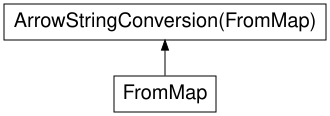

In [11]:
ddf.visualize(format='svg') # This visualization is very large, and using `format='svg'` will make it easier to view.

As you can see, when we indicate for Dask to actually execute this operation, it will parallelize the work across the 4 GPUs in something like 69 parallel partitions. We can see the exact number of partitions with the `npartitions` property:

In [12]:
ddf.npartitions

69

### Extending the Computational Graph ###
The concept of constructing computational graphs with arbitrary operations before executing them is a core part of Dask. Let's add some operations to the existing computational graph and visualize it again.

After running the next cell, although it will take some scrolling to get a clear sense of it (the challenges of distributed data analytics!), you can see that the graph already constructed for `read_csv` now continues upward. It selects the `age` column across all partitions (visualized as `getitem`) and eventually performs the `.mean()` reduction (visualized as `series-sum-chunk`, `series-sum-agg`, `count-chunk`, `sum-agg` and `true-div`).

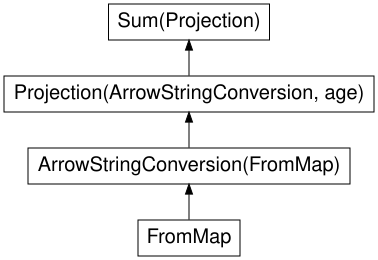

In [13]:
mean_age = ddf['age'].sum()
mean_age.visualize(format='svg')

### Computing with the Computational Graph ###
There are several ways to indicate to Dask that we would like to perform the computations described in the computational graphs we have constructed. The first we will show is the `.compute` method, which will return the output of the computation as an object in one GPU's memory - no longer distributed across GPUs.

**NOTE**: This value is actually a [*future*](https://docs.python.org/3/library/concurrent.futures.html) that it can be immediately used in code, even before it completes evaluating. While this can be tremendously useful in many scenarios, we will not need in this workshop to do anything fancy with the futures we generate except to wait for them to evaluate so we can visualize their values.

Below we send the computational graph we have created to the Dask scheduler to be executed in parallel on our 4 GPUs. If you have the Dask Dashboard open on another tab from before, you can watch it while the operation completes. Because our graph involves reading the entire 18GB data set (as we declared when adding `read_csv` to the call graph), you can expect the operation to take a little time. If you closely watch the dashboard, you will see that Dask begins follow-on calculations for `mean` even while data is still being read into memory.

In [14]:
mean_age.compute()

np.float32(11732293000.0)

### Persisting Data in the Cluster ###
As you can see, the previous operation, which read the entire 18GB csv into the GPUs' memory, did not retain the data in memory after completing the computational graph:

In [15]:
!nvidia-smi

Wed Jul 22 06:08:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             34W /   70W |     221MiB /  15360MiB |     60%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

A typical Dask workflow, which we will utilize, is to persist data we would like to work with to the cluster and then perform fast operations on that persisted data. We do this with the `.persist` method. From the [Dask documentation](https://distributed.dask.org/en/latest/manage-computation.html#client-persist):

>The `.persist` method submits the task graph behind the Dask collection to the scheduler, obtaining Futures for all of the top-most tasks (for example one Future for each Pandas [*or cuDF*] DataFrame in a Dask[*-cudf*] DataFrame). It then returns a copy of the collection pointing to these futures instead of the previous graph. This new collection is semantically equivalent but now points to actively running data rather than a lazy graph.

Below we persist `ddf` to the cluster so that it will reside in GPU memory for us to perform fast operations on.

In [16]:
ddf = ddf.persist()

As you can see by executing `nvidia-smi` (after letting the `persist` finish), each GPU now has parts of the distributed dataframe in its memory:

In [17]:
!nvidia-smi

Wed Jul 22 06:08:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             35W /   70W |     711MiB /  15360MiB |     57%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Running `ddf.visualize` now shows that we no longer have operations in our task graph, only partitions of data, ready for us to perform operations:

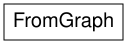

In [18]:
ddf.visualize(format='svg')

Computing operations on this data will now be much faster:

In [19]:
ddf['age'].mean().compute()

np.float64(40.1241924549316)

## Initial Data Exploration with Dask cuDF ##
The beauty of Dask is that working with your data, even though it is distributed and massive, is a lot like working with smaller in-memory data sets.

In [20]:
ddf.head() # As a convenience, no need to `.compute` the `head()` method

,age,sex,county,lat,long,name
0,0.0,m,Darlington,54.549641,-1.493884,HARRISON
1,0.0,m,Darlington,54.523945,-1.401142,LAKSH
2,0.0,m,Darlington,54.561127,-1.690068,MUHAMMAD
3,0.0,m,Darlington,54.542988,-1.543216,GRAYSON
4,0.0,m,Darlington,54.532101,-1.569116,FINLAY


In [21]:
ddf.count().compute()

age       292399470
sex       292399470
county    292399470
lat       292399470
long      292399470
name      292399470
dtype: int64

In [22]:
ddf.dtypes

,0
age,float32
sex,object
county,object
lat,float32
long,float32
name,object


### Exercise #1 - Counties North of Sunderland with Dask ###
Here we ask you to revisit an earlier exercise, but on the distributed data set. Hopefully, it's clear how similar the code is for single-GPU dataframes and distributed dataframes with Dask.

Identify the latitude of the northernmost resident of Sunderland county (the person with the maximum `lat` value), and then determine which counties have any residents north of this resident. Use the `unique` method of a cudf `Series` to de-duplicate the result.

**Instructions**: <br>
* Modify the `<FIXME>` only and execute the below cell to identify counties north of Sunderland.

In [ ]:
sunderland_residents = ddf.loc[<<<<FIXME>>>>]
northmost_sunderland_lat = sunderland_residents['lat'].max()
counties_with_pop_north_of = ddf.loc[ddf['lat'] > northmost_sunderland_lat]['county'].unique()
results=counties_with_pop_north_of.compute()
results.head()

<details style='border:1px solid #d0d7de; border-radius:10px; padding:0.45em 0.8em; background:linear-gradient(180deg,#f8fbff 0%,#ffffff 100%); box-shadow:0 1px 3px rgba(0,0,0,0.06);'>
<summary style='font-weight:600; color:#0b57d0; cursor:pointer;'>Show Solution</summary>

```python
sunderland_residents = ddf.loc[ddf['county'] == 'Sunderland']
northmost_sunderland_lat = sunderland_residents['lat'].max()
counties_with_pop_north_of = ddf.loc[ddf['lat'] > northmost_sunderland_lat]['county'].unique()
results=counties_with_pop_north_of.compute()
results.head()
```
</details>